# Задание 1.1.1

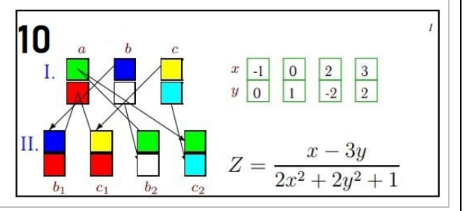

In [1]:
import numpy as np

In [2]:
def qZ(x, y):
    return (x - 3 * y) / (2 * x**2 + 2 * y**2 + 1)

In [3]:
def qNet(x, y, fitness_func):
    q = np.array([fitness_func(x[i], y[i]) for i in range(len(x))])
    return q

In [4]:
def exchangeData(x, y, sort_indices):
    x_new1 = (x[sort_indices[-1]] + x[sort_indices[-2]]) / 2
    y_new1 = (y[sort_indices[-1]] + y[sort_indices[-2]]) / 2
    
    x_new2 = (x[sort_indices[-1]] + x[sort_indices[-3]]) / 2
    y_new2 = (y[sort_indices[-1]] + y[sort_indices[-3]]) / 2
    
    return x_new1, y_new1, x_new2, y_new2

In [5]:
x = np.array([-1, 0, 2, 3], dtype=float)
y = np.array([0, 1, -2, 2], dtype=float)

In [6]:
res = qNet(x, y, qZ)
print(f"Значения функции качества: {res}")

Значения функции качества: [-0.33333333 -1.          0.47058824 -0.11111111]


In [7]:
sort_indices = np.argsort(res)
print(f"Порядковые номера особей после сортировки: {sort_indices}")

Порядковые номера особей после сортировки: [1 0 3 2]


In [8]:
x_n1, y_n1, x_n2, y_n2 = exchangeData(x, y, sort_indices)

In [9]:
x[sort_indices[0]], y[sort_indices[0]] = x_n1, y_n1
x[sort_indices[1]], y[sort_indices[1]] = x_n2, y_n2

In [10]:
res_new = qNet(x, y, qZ)

In [11]:
print("\n--- Результаты первого шага ---")
for i in range(len(x)):
    print(f"Особь {i+1}: x={x[i]:.2f}, y={y[i]:.2f}, Z={res_new[i]:.4f}")


--- Результаты первого шага ---
Особь 1: x=0.50, y=-1.00, Z=1.0000
Особь 2: x=2.50, y=0.00, Z=0.1852
Особь 3: x=2.00, y=-2.00, Z=0.4706
Особь 4: x=3.00, y=2.00, Z=-0.1111


In [12]:
print(f"\nЛучшее значение функции в новой популяции: {np.max(res_new):.4f}")


Лучшее значение функции в новой популяции: 1.0000


# Задание 1.2.1

*Найти длину гамильтонова цикла S4 в полном графе K6 после четырех циклов решения задачи методом отжига по вариантам ниже.*

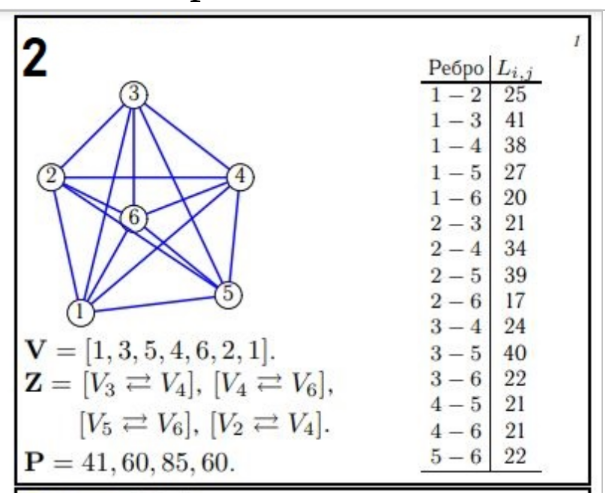

In [32]:
import math

In [33]:
distances = {
    (1,2): 25, (1,3): 41, (1,4): 38, (1,5): 27, (1,6): 20,
    (2,3): 21, (2,4): 34, (2,5): 39, (2,6): 17,
    (3,4): 24, (3,5): 40, (3,6): 22,
    (4,5): 21, (4,6): 21,
    (5,6): 22
}

In [34]:
def get_d(a, b):
    return distances.get(tuple(sorted((a, b))))

In [35]:
def calc_length(v):
    return sum(get_d(v[i], v[i+1]) for i in range(len(v)-1))

In [36]:
V = [1, 3, 5, 4, 6, 2, 1]
Z = [(3, 4), (4, 6), (5, 6), (2, 4)]
P_vals = [41, 60, 85, 60]
T = 100

In [37]:
print(f"S0 (исходный): {V}, Длина = {calc_length(V)}")

S0 (исходный): [1, 3, 5, 4, 6, 2, 1], Длина = 165


In [38]:
for i in range(len(Z)):
    idx1, idx2 = Z[i][0] - 1, Z[i][1] - 1
    
    new_V = V.copy()
    new_V[idx1], new_V[idx2] = new_V[idx2], new_V[idx1]
    
    old_S = calc_length(V)
    new_S = calc_length(new_V)
    delta_S = new_S - old_S
    
    print(f"\nИтерация {i+1} (T={T}):")
    print(f"Замена {Z[i]}: {new_V}, Длина = {new_S}")
    
    if delta_S <= 0:
        V = new_V
        print("Принято (путь короче)")
    else:
        P_calc = 100 * math.exp(-delta_S / T)
        print(f"delta_S = {delta_S}, P_расч = {P_calc:.2f}, P_зад = {P_vals[i]}")
        if P_calc > P_vals[i]:
            V = new_V
            print("Принято по вероятности")
        else:
            print("Отказ (путь не меняем)")
    
    T *= 0.5



Итерация 1 (T=100):
Замена (3, 4): [1, 3, 4, 5, 6, 2, 1], Длина = 150
Принято (путь короче)

Итерация 2 (T=50.0):
Замена (4, 6): [1, 3, 4, 2, 6, 5, 1], Длина = 165
delta_S = 15, P_расч = 74.08, P_зад = 60
Принято по вероятности

Итерация 3 (T=25.0):
Замена (5, 6): [1, 3, 4, 2, 5, 6, 1], Длина = 180
delta_S = 15, P_расч = 54.88, P_зад = 85
Отказ (путь не меняем)

Итерация 4 (T=12.5):
Замена (2, 4): [1, 2, 4, 3, 6, 5, 1], Длина = 154
Принято (путь короче)


In [39]:
print(f"\nИтоговый цикл S4: {V}")
print(f"Длина S4: {calc_length(V)}")


Итоговый цикл S4: [1, 2, 4, 3, 6, 5, 1]
Длина S4: 154


# Задание *

*На решенном уже примере поэкспериментируйте с показателем S, проанализируйте результаты.*

1. Сценарий "Легкое ухудшение": когда новый путь лишь немного длиннее текущего.
2. Сценарий "Критическое ухудшение": когда новый путь значительно хуже текущего.

In [49]:
import math
import matplotlib.pyplot as plt

In [50]:
def calculate_probability(delta_s, temperature):
    return 100 * math.exp(-delta_s / temperature)

In [51]:
temperatures = [100, 50, 25, 12.5]
delta_s_small = 10
delta_s_large = 50

In [52]:
print(f"{'Т (Темп.)':<10} | {'P (при dS=10)':<15} | {'P (при dS=50)':<15}")
print("-" * 45)

results_small = []
results_large = []

for t in temperatures:
    p_small = calculate_probability(delta_s_small, t)
    p_large = calculate_probability(delta_s_large, t)
    results_small.append(p_small)
    results_large.append(p_large)
    print(f"{t:<10} | {p_small:.2f}%{'':<8} | {p_large:.2f}%")

Т (Темп.)  | P (при dS=10)   | P (при dS=50)  
---------------------------------------------
100        | 90.48%         | 60.65%
50         | 81.87%         | 36.79%
25         | 67.03%         | 13.53%
12.5       | 44.93%         | 1.83%


In [53]:
print("\n--- Анализ ---")
print(f"1. При Т=100 вероятность принять небольшое ухудшение (dS=10) очень высока: {results_small[0]:.1f}%.")
print(f"2. При той же Т=100 вероятность принять критическое ухудшение (dS=50) падает до {results_large[0]:.1f}%.")
print(f"3. На последнем шаге (Т=12.5) шанс принять dS=50 практически равен нулю ({results_large[-1]:.4f}%).")


--- Анализ ---
1. При Т=100 вероятность принять небольшое ухудшение (dS=10) очень высока: 90.5%.
2. При той же Т=100 вероятность принять критическое ухудшение (dS=50) падает до 60.7%.
3. На последнем шаге (Т=12.5) шанс принять dS=50 практически равен нулю (1.8316%).
